In [19]:
import re
import math
import zlib
import statistics
from collections import Counter

def extract_top_features(code):
    if not code or not code.strip():
        return None

    lines = code.split('\n')
    
    # Feature 1: std line length / avg line length
    non_empty_lines = [len(line) for line in lines if line.strip()]
    if len(non_empty_lines) > 1:
        avg_line_len = statistics.mean(non_empty_lines)
        std_line_len = statistics.stdev(non_empty_lines)
        cv_line_len = std_line_len / avg_line_len if avg_line_len > 0 else 0
    else:
        cv_line_len = 0.0

    # Find words (keywords + variables + func names + ...)
    words = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)

    # Feature 2: avg words length
    if words:
        avg_id_len = sum(len(w) for w in words) / len(words)
    else:
        avg_id_len = 0.0

    # Feature 3: blank line ratio (blank lines / total lines)
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / len(lines) if lines else 0.0

    # Feature 4: compression ratio 
    code_bytes = code.encode('utf-8')
    compressed_bytes = zlib.compress(code_bytes)
    compression_ratio = len(compressed_bytes) / len(code_bytes)

    # Feature 5: words entropy 
    if words:
        word_counts = Counter(words)
        total_words = len(words)
        
        entropy = 0.0
        for count in word_counts.values():
            p = count / total_words
            entropy -= p * math.log2(p)
    else:
        entropy = 0.0

    return {
        "line_length": round(cv_line_len, 4),        # std / avg
        "word_length": round(avg_id_len, 4) / 5,
        "blank_line": round(blank_line_ratio, 4),
        "compression": round(compression_ratio, 4),
        "word_entropy": (round(entropy, 4) - 3) / 2
    }

# import re
# import statistics

# def extract_top_features(code):
#     if not code or not code.strip():
#         return {
#             "cv_line_length": 0.0,
#             "deep_indent_ratio": 0.0,
#             "assign_op_ratio": 0.0,
#             "proper_comment_ratio": 0.0,
#             "inline_comment_ratio": 0.0
#         }

#     # --- 1. std line length / mean line length (Hệ số biến thiên chiều dài dòng) ---
#     lines = code.split('\n')
#     non_empty_lines = [len(l) for l in lines if l.strip()]
#     cv_line_len = 0.0
#     if len(non_empty_lines) > 1:
#         mean_l = statistics.mean(non_empty_lines)
#         if mean_l > 0:
#             cv_line_len = statistics.stdev(non_empty_lines) / mean_l

#     # --- 2. Tỷ lệ dòng thụt lề sâu (>= 3 cấp / 12 spaces / 3 tabs) ---
#     deep_lines = 0
#     for l in lines:
#         if not l.strip(): continue
#         # Dùng expandtabs(4) quy đổi mọi Tab thành 4 khoảng trắng để đo cho chuẩn
#         expanded_l = l.expandtabs(4)
#         leading_spaces = len(expanded_l) - len(expanded_l.lstrip())
#         if leading_spaces >= 12: # Định nghĩa >= 3 cấp là thụt sâu
#             deep_lines += 1
#     deep_indent_ratio = deep_lines / len(non_empty_lines) if non_empty_lines else 0.0

#     # TIỀN XỬ LÝ (Rất quan trọng): Xóa tất cả String/Char literal ("...", '...')
#     # Để tránh việc đếm nhầm dấu '=' hoặc comment marker nằm bên trong chuỗi.
#     clean_code = re.sub(r'"[^"\\]*(?:\\.[^"\\]*)*"|\'[^\'\\]*(?:\\.[^\'\\]*)*\'', '""', code)

#     # --- 4 & 5. Phân tích Comment ---
#     total_comments = 0
#     proper_comments = 0
#     inline_comments = 0

#     # Xử lý Single-line comment (// hoặc #)
#     # Group 1: Code trước comment, Group 2: Dấu comment, Group 3: Nội dung comment
#     single_line_pattern = re.compile(r'^(.*?)(//|#)(.*)$', re.MULTILINE)
#     for match in single_line_pattern.finditer(clean_code):
#         prefix = match.group(1).strip()
#         content = match.group(3).strip()
#         total_comments += 1

#         if prefix: # Nếu phía trước dấu comment CÓ code -> Đây là comment cuối dòng
#             inline_comments += 1

#         if content and content[0].isupper() and content[-1] == '.':
#             proper_comments += 1

#     # Xử lý Multi-line comment (/* ... */)
#     block_pattern = re.compile(r'^(.*?)/\*+(.*?)\*+/', re.MULTILINE | re.DOTALL)
#     for match in block_pattern.finditer(clean_code):
#         prefix = match.group(1).strip()
#         content = match.group(2).strip()
#         total_comments += 1

#         if prefix:
#             inline_comments += 1

#         # Gộp các dòng trong block comment lại để check câu
#         clean_content = " ".join(content.split()).strip()
#         if clean_content and clean_content[0].isupper() and clean_content[-1] == '.':
#             proper_comments += 1

#     proper_comment_ratio = proper_comments / total_comments if total_comments > 0 else 0.0
#     inline_comment_ratio = inline_comments / total_comments if total_comments > 0 else 0.0

#     # --- 3. Tỷ lệ Phép gán / Phép toán ---
#     # Tiền xử lý: Xóa sạch comment để chỉ đếm toán tử trong code thực sự
#     code_no_comments = re.sub(r'//.*|#.*|/\*.*?\*/', '', clean_code, flags=re.DOTALL)
    
#     # Tìm mọi cụm ký tự là toán tử (+, -, =, ==, +=, &&, ||, <, > ...)
#     operators = re.findall(r'[+\-*/%=<>!&|^~]+', code_no_comments)
#     total_ops = 0
#     assignments = 0

#     for op in operators:
#         # Loại trừ các phép so sánh thuần túy (không phải gán)
#         if op in ['==', '!=', '<=', '>=', '===', '!==']:
#             total_ops += 1
#         # Phép gán: Kết thúc bằng '=' nhưng không nằm trong nhóm so sánh (VD: =, +=, -=, *=)
#         elif op.endswith('='):
#             assignments += 1
#             total_ops += 1
#         else:
#             total_ops += 1 # Các phép toán số học, logic bình thường (+, -, *, &&)

#     assign_op_ratio = assignments / total_ops if total_ops > 0 else 0.0

#     return {
#         "line_length": round(cv_line_len, 4),
#         "deep_indent": round(deep_indent_ratio, 4),
#         "assign_op": round(assign_op_ratio, 4),
#         "proper_comment": round(proper_comment_ratio, 4),
#         "inline_comment": round(inline_comment_ratio, 4)
#     }

# # --- TEST ---
# sample = """
# def calculate_salary(base, bonus):
#     # This function calculates the final salary.
#     total = base + bonus # add bonus
    
#     if total > 1000:
#         for i in range(3):
#             if i == 1:
#                 total += 100  // Deeply indented assign
    
#     return total
# """
# print(extract_top_features(sample))


# --- Test ---
ai_code = """
import math

def is_prime(n):
    if n < 2:
        return False
    if n == 2:
        return True
    if n % 2 == 0:
        return False
    for i in range(3, int(math.isqrt(n)) + 1, 2):
        if n % i == 0:
            return False
    return True

n = int(input())
a = list(map(int, input().split()))

min_prime = -1

for x in a:
    if is_prime(x):
        if min_prime == -1 or x < min_prime:
            min_prime = x

print(min_prime)
"""

human_code = """
(a, b, c, d) = [int(x) for x in input().split()]
k = input()
(p, q, r, s) = (0, 0, 0, 0)
for i in k:
	if i == '1':
		p += 1
	elif i == '2':
		q += 1
	elif i == '3':
		r += 1
	elif i == '4':
		s += 1
print(a * p + b * q + c * r + d * s)
"""

ai_features = extract_top_features(ai_code)
human_features = extract_top_features(human_code)

for k, v in ai_features.items():
    print(f"{k}: {v}")

print("\n--------------\nHuman:")
for k, v in human_features.items():
    print(f"{k}: {v}")

line_length: 0.4907
word_length: 0.74482
blank_line: 0.2593
compression: 0.4586
word_entropy: 0.6368499999999999

--------------
Human:
line_length: 0.723
word_length: 0.3619
blank_line: 0.1333
compression: 0.6287
word_entropy: 0.5606499999999999


In [63]:
import re
import numpy as np
from collections import Counter

import re

def extract_top_features(code):
    if not code or not code.strip():
        return {
            "blank_line": 0.0,
            "whitespace_ratio": 0.0,
            "irregular_indent": 0.0,
            "space_tab": 0.0,
            "naming": 0.0
        }

    # Feat 1: blank lines ratio
    lines = code.strip().split('\n')
    total_lines = len(lines)
    
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / total_lines if total_lines > 0 else 0.0

    # Feat 2: whitespace ratio
    total_chars = len(code.strip())
    whitespace_count = sum(1 for char in code.strip() if char == ' ') + sum(1 for char in code.strip() if char == '\t') 
    whitespace_ratio = whitespace_count / total_chars if total_chars > 0 else 0.0

    # Feat 3: comment ratio
    # Find '//' and '#'
    comment_lines = sum(1 for line in lines if re.search(r'(?://|#)', line))
    comment_ratio = comment_lines / total_lines if total_lines > 0 else 0.0

    words = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)
    total_words = len(words)

    # Feat 4: identifier style
    tokens = re.findall(r'[A-Za-z_][A-Za-z0-9_]*', code)
    if not tokens:
        style_ratio = 0.0
    else:
        def get_type(t):
            if '_' in t and t.lower() == t:
                return 'snake'
            elif re.search(r'[a-z][A-Z]', t):
                return 'camel'
            elif t.isupper():
                return 'upper'
            else:
                return 'other'

        types = [get_type(t) for t in tokens]
        cnt = Counter(types)

        style_ratio = max(cnt.values()) / len(tokens)

    # Feat 5: lines / spaces
    spaces = code.count(' ')
    tabs = 4 * code.count('\n')
    # lines_per_space = abs(1 - total_words / num_spaces) if num_spaces > 0 else 0.0
    lines_per_space = abs(spaces - tabs) / (1.0 * spaces + tabs) if (spaces + tabs > 0) else 0.0

    return {
        "blank_line": round(blank_line_ratio, 4),
        "whitespace_ratio": round(whitespace_ratio, 4),
        "irregular_indent": round(comment_ratio, 4),
        "space_tab": round(style_ratio, 4),
        "naming": round(lines_per_space, 4)
    }

code = """
(a, b, c, d) = [int(x) for x in input().split()]
k = input()
(p, q, r, s) = (0, 0, 0, 0)
for i in k:
	if i == '1':
		p += 1
	elif i == '2':
		q += 1
	elif i == '3':
		r += 1
	elif i == '4':
		s += 1
print(a * p + b * q + c * r + d * s)
"""

feats = extract_top_features(code)
for k, v in feats.items():
    print(f"{k}: {v}")


blank_line: 0.0
whitespace_ratio: 0.2894
irregular_indent: 0.0
space_tab: 1.0
naming: 0.0


# Get code lists

In [3]:
import pandas as pd

df = pd.read_parquet("../data/validation.parquet")

human_codes = df[df["label"] == 0]["code"].tolist()
ai_codes = df[df["label"] == 1]["code"].tolist()

print(len(human_codes), len(ai_codes))

47695 52305


In [4]:
df = pd.read_parquet("../data/test_sample.parquet")

test_human_codes = df[df["label"] == 0]["code"].tolist()
test_ai_codes = df[df["label"] == 1]["code"].tolist()

print(len(test_human_codes), len(test_ai_codes))

777 223


# Mean & std of features

In [ ]:
import numpy as np

def features_statistics(codes: list, return_lists=False):
    """ 
    This function returns the statistics of the 5 features, computing accross a list of codes.
    
    Returns:
        [mean, std] of each feature if return_lists = False
        lists of each feature values if return_lists = True
    """
    # line_lengths = []
    # word_lengths = []
    # blank_line_ratios = []
    # compression_ratios = []
    # word_entropies = []
    feat1 = []; feat2 = []; feat3 = []; feat4 = []; feat5 = []

    for code in codes:
        features = extract_top_features(code)
        feat1.append(features["line_length"])
        feat2.append(features["word_length"])
        feat3.append(features["blank_line"])
        feat4.append(features["compression"])
        feat5.append(features["word_entropy"])

        # feat1.append(features["line_length"])
        # feat2.append(features["deep_indent"])
        # feat3.append(features["assign_op"])
        # feat4.append(features["proper_comment"])
        # feat5.append(features["inline_comment"])
    
    if (return_lists):
        return [feat1, feat2, feat3, feat4, feat5]
    
    statistics = {
        "line_length": [round(np.mean(feat1), 3), round(np.std(feat1), 3)],
        "deep_indent": [round(np.mean(feat2), 3), round(np.std(feat2), 3)],
        "assign_op": [round(np.mean(feat3), 3), round(np.std(feat3), 3)],
        "proper_comment": [round(np.mean(feat4), 3), round(np.std(feat4), 3)],
        "inline_comment": [round(np.mean(feat5), 3), round(np.std(feat5), 3)],
    }

    return statistics

# Test -----
exp_ai_codes = ai_codes[:]
exp_human_codes = human_codes[:]

print("--- Human:")
human_stt = features_statistics(exp_human_codes)
for k, v in human_stt.items():
    print(f"{k}: {v}")

print("\n--- AI:")
ai_stt = features_statistics(exp_ai_codes)
for k, v in ai_stt.items():
    print(f"{k}: {v}")
    


### 3 features

In [6]:
import numpy as np

def features_statistics(codes: list, return_lists=False):
    """ 
    This function returns the statistics of the 2 features, computing accross a list of codes.
    
    Returns:
        [mean, std] of each feature if return_lists = False
        lists of each feature values if return_lists = True
    """
    feat1 = []; feat2 = []; feat3 = []; feat4 = []; feat5 = []

    for code in codes:
        features = extract_top_features(code)
        feat1.append(features["blank_line"])
        feat2.append(features["whitespace_ratio"])
        feat3.append(features["irregular_indent"])
        feat4.append(features["space_tab"])
        feat5.append(features["naming"])
    
    if (return_lists):
        return [feat1, feat2, feat3, feat4, feat5]
    
    statistics = {
        "blank_line": [round(np.mean(feat1), 3), round(np.std(feat1), 3)],
        "whitespace_ratio": [round(np.mean(feat2), 3), round(np.std(feat2), 3)],
        "irregular_indent": [round(np.mean(feat3), 3), round(np.std(feat3), 3)],
        "space_tab": [round(np.mean(feat4), 3), round(np.std(feat4), 3)],
        "naming": [round(np.mean(feat5), 3), round(np.std(feat5), 3)]
    }

    return statistics

# Test -----
exp_ai_codes = ai_codes[:100]
exp_human_codes = human_codes[:100]

print("--- Human:")
human_stt = features_statistics(exp_human_codes)
for k, v in human_stt.items():
    print(f"{k}: {v}")

print("\n--- AI:")
ai_stt = features_statistics(exp_ai_codes)
for k, v in ai_stt.items():
    print(f"{k}: {v}")
    


--- Human:
blank_line: [0.069, 0.153]
whitespace_ratio: [0.412, 1.166]
irregular_indent: [0.025, 0.058]
space_tab: [0.93, 0.086]
naming: [0.257, 0.15]

--- AI:
blank_line: [0.158, 0.1]
whitespace_ratio: [0.274, 0.222]
irregular_indent: [0.095, 0.157]
space_tab: [0.891, 0.097]
naming: [0.29, 0.151]


In [21]:
exp_ai_codes = ai_codes[15000:17000]
exp_human_codes = human_codes[15000:17000]

print("--- Human:")
human_stt = features_statistics(exp_human_codes)
for k, v in human_stt.items():
    print(f"{k}: {v}")

print("\n--- AI:")
ai_stt = features_statistics(exp_ai_codes)
for k, v in ai_stt.items():
    print(f"{k}: {v}")

--- Human:
line_length: [0.566, 0.177]
deep_indent: [0.63, 0.161]
assign_op: [0.111, 0.112]
proper_comment: [0.587, 0.156]
inline_comment: [0.568, 0.334]

--- AI:
line_length: [0.679, 0.306]
deep_indent: [0.804, 0.218]
assign_op: [0.152, 0.11]
proper_comment: [0.486, 0.149]
inline_comment: [0.915, 0.505]


# Diagrams

In [98]:
import re
import numpy as np
from collections import Counter
import math

def extract_top_features(code):
    if not code or not code.strip():
        return {
            "blank_line": 0.0,
            "whitespace_ratio": 0.0,
            "irregular_indent": 0.0,
            "space_tab": 0.0,
            "naming": 0.0
        }

    # Feat 1: blank lines ratio
    lines = code.strip().split('\n')
    total_lines = len(lines)
    
    blank_lines = sum(1 for line in lines if not line.strip())
    blank_line_ratio = blank_lines / total_lines if total_lines > 0 else 0.0

    # Feat 2: whitespace ratio
    whitespaces = [l.count(' ') + 4 * l.count('\t') for l in lines]
    whitespace_ratio = np.std(whitespaces) / np.mean(whitespaces) if len(whitespaces) > 0 else 0.0

    # Feat 3: comment ratio
    # Find '//' and '#'
    comment_lines = sum(1 for line in lines if re.search(r'(?://|#)', line))
    comment_ratio = comment_lines / total_lines if total_lines > 0 else 0.0

    words = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]*\b', code)
    total_words = len(words)

    # Feat 4: identifier style
    tokens = re.findall(r'[A-Za-z_][A-Za-z0-9_]*', code)
    if not tokens:
        style_ratio = 0.0
    else:
        def get_type(t):
            if '_' in t and t.lower() == t:
                return 'snake'
            elif re.search(r'[a-z][A-Z]', t):
                return 'camel'
            elif t.isupper():
                return 'upper'
            else:
                return 'other'

        types = [get_type(t) for t in tokens]
        cnt = Counter(types)

        style_ratio = max(cnt.values()) / len(tokens)

    # Feat 5: lines / spaces
    spaces = code.count(' ')
    tabs = 4 * code.count('\n')
    # lines_per_space = abs(1 - total_words / num_spaces) if num_spaces > 0 else 0.0
    lines_per_space = abs(spaces - tabs) / (1.0 * spaces + tabs) if (spaces + tabs > 0) else 0.0

    return {
        "blank_line": round(blank_line_ratio, 4),
        "whitespace_ratio": round(whitespace_ratio, 4),
        "irregular_indent": round(comment_ratio, 4),
        "space_tab": round(style_ratio, 4),
        "naming": round(lines_per_space, 4)
    }

In [99]:
human_feat_lists = features_statistics(human_codes[10000:12000], return_lists=True)
ai_feat_lists = features_statistics(ai_codes[10000:12000], return_lists=True)

test_human_feat_lists = features_statistics(test_human_codes, return_lists=True)
test_ai_feat_lists = features_statistics(test_ai_codes, return_lists=True)

C:\Users\Dell\AppData\Local\Temp\ipykernel_17400\839499340.py:25: RuntimeWarning: invalid value encountered in scalar divide
  whitespace_ratio = np.std(whitespaces) / np.mean(whitespaces) if len(whitespaces) > 0 else 0.0


### 1D Diagram (1 feature)

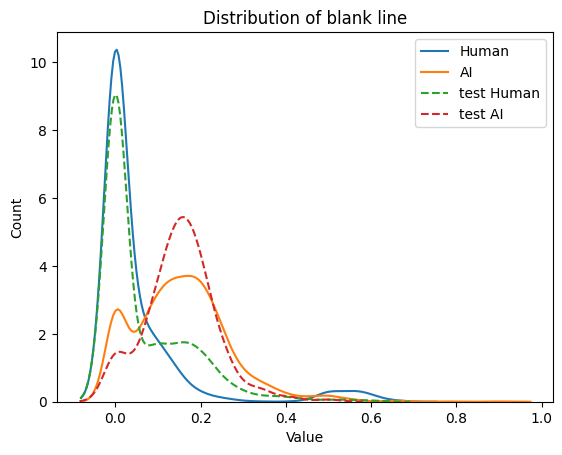

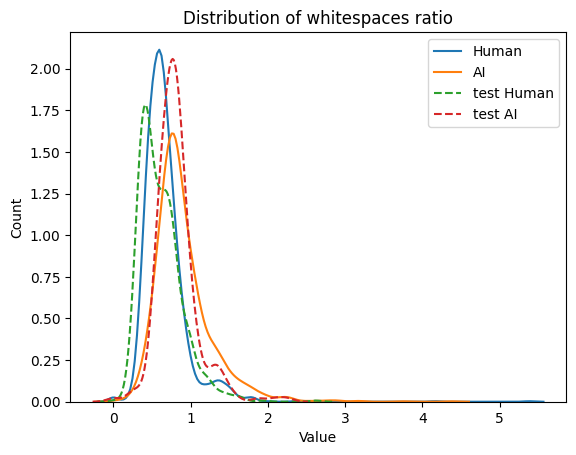

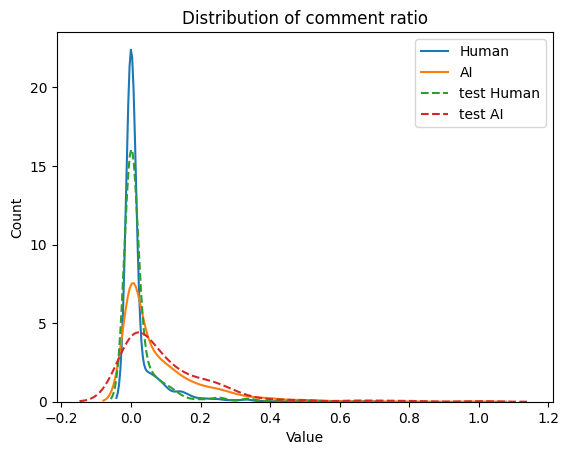

In [100]:
import seaborn as sns
import matplotlib.pyplot as plt

# feat_names = ["line length", "deep indent", "assign operation", "proper comment", "inline comment"]
# feat_names = ["line length", "word length", "blank lines", "compression", "word entropy"]
feat_names = ["blank line", "whitespaces ratio", "comment ratio", "identifiers style", "spaces / (spaces + 4*tabs)"]

for feat_idx in [0, 1, 2]:
    human = [x for x in human_feat_lists[feat_idx] if x < 200]
    ai = [x for x in ai_feat_lists[feat_idx] if x < 200]

    test_human = [x for x in test_human_feat_lists[feat_idx] if x < 200]
    test_ai = [x for x in test_ai_feat_lists[feat_idx] if x < 200]

    plt.figure()

    sns.kdeplot(human, label="Human")
    sns.kdeplot(ai, label="AI")

    sns.kdeplot(test_human, label="test Human", linestyle="--")
    sns.kdeplot(test_ai, label="test AI", linestyle="--")

    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title("Distribution of " + feat_names[feat_idx])
    plt.legend()
    plt.show()


### 2D diagram (2 features)

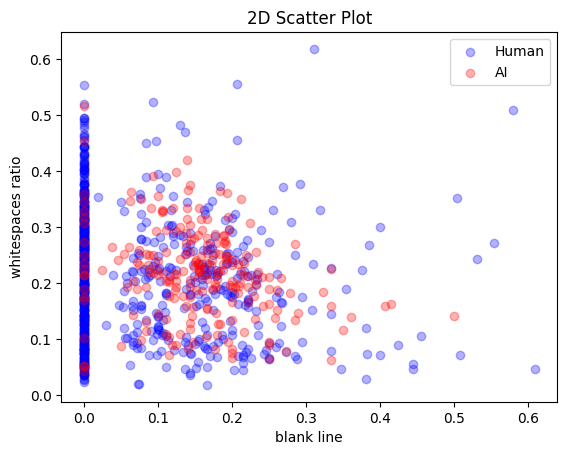

In [24]:
feat_names = ["blank line", "whitespaces ratio", "comment ratio", "identifiers style", "spaces / (spaces + 4*tabs)"]

idx1, idx2 = 0, 1

human1 = np.clip([x for x in test_human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in test_human_feat_lists[idx2]], 0, 2)
ai1 = np.clip([x for x in test_ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in test_ai_feat_lists[idx2]], 0, 2)

# human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
# human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
# ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
# ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)


import matplotlib.pyplot as plt

plt.figure()

plt.scatter(human1, human2, color='blue', alpha=0.3, label="Human")
plt.scatter(ai1, ai2, color='red', alpha=0.3, label="AI")

plt.xlabel(feat_names[idx1])
plt.ylabel(feat_names[idx2])
plt.title("2D Scatter Plot")

plt.legend()

plt.show()


### 3D diagram

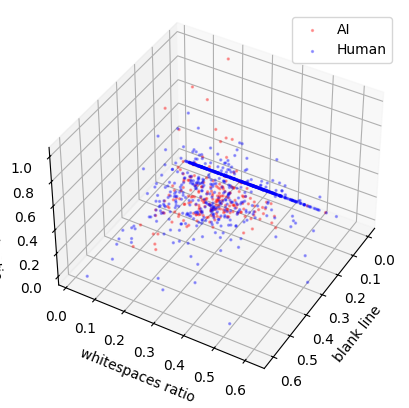

In [27]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

feat_names = ["blank line", "whitespaces ratio", "comment ratio", "identifiers style", "spaces / (spaces + 4*tabs)"]
idx1, idx2, idx3 = 0, 1, 2

# human1 = np.clip([x for x in human_feat_lists[idx1]], 0, 2)
# human2 = np.clip([x for x in human_feat_lists[idx2]], 0, 2)
# human3 = np.clip([x for x in human_feat_lists[idx3]], 0, 2)
# ai1 = np.clip([x for x in ai_feat_lists[idx1]], 0, 2)
# ai2 = np.clip([x for x in ai_feat_lists[idx2]], 0, 2)
# ai3 = np.clip([x for x in ai_feat_lists[idx3]], 0, 2)

human1 = np.clip([x for x in test_human_feat_lists[idx1]], 0, 2)
human2 = np.clip([x for x in test_human_feat_lists[idx2]], 0, 2)
human3 = np.clip([x for x in test_human_feat_lists[idx3]], 0, 2)
ai1 = np.clip([x for x in test_ai_feat_lists[idx1]], 0, 2)
ai2 = np.clip([x for x in test_ai_feat_lists[idx2]], 0, 2)
ai3 = np.clip([x for x in test_ai_feat_lists[idx3]], 0, 2)

ax.scatter(ai1, ai2, ai3, color='red', alpha=0.3, s = 2, label="AI")
ax.scatter(human1, human2, human3, color='blue', alpha=0.3, s = 2, label="Human")

ax.set_xlabel(feat_names[idx1])
ax.set_ylabel(feat_names[idx2])
ax.set_zlabel(feat_names[idx3])

ax.view_init(elev=40, azim=30)
ax.legend()

plt.show()


In [94]:
# !python -m pip install plotly
!python -m pip install nbformat>=4.2.0

In [13]:
import plotly.express as px
import pandas as pd

# Choose features
feat_names = ["blank line", "whitespaces ratio", "comment ratio", "identifiers style", "spaces / (spaces + 4*tabs)"]
idx1, idx2, idx3 = 0, 1, 2

human1 = np.clip([x for x in human_feat_lists[idx1][:10000]], 0, 2)
human2 = np.clip([x for x in human_feat_lists[idx2][:10000]], 0, 2)
human3 = np.clip([x for x in human_feat_lists[idx3][:10000]], 0, 2)
ai1 = np.clip([x for x in ai_feat_lists[idx1][:10000]], 0, 2)
ai2 = np.clip([x for x in ai_feat_lists[idx2][:10000]], 0, 2)
ai3 = np.clip([x for x in ai_feat_lists[idx3][:10000]], 0, 2)

feat1, feat2, feat3 = feat_names[idx1], feat_names[idx2], feat_names[idx3] 

df_human = pd.DataFrame({
    feat1: human1,
    feat2: human2,
    feat3: human3,
    "label": ["Human"] * len(human1)
})

df_ai = pd.DataFrame({
    feat1: ai1,
    feat2: ai2,
    feat3: ai3,
    "label": ["AI"] * len(ai1)
})

df = pd.concat([df_human, df_ai], ignore_index=True)

fig = px.scatter_3d(df, x=feat1, y=feat2, z=feat3, color='label')
fig.update_traces(marker=dict(size=2), opacity=0.4)
fig.show()
